In [57]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

In [58]:
# Data loading config params

SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [ ]:
# Helper methods

def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())

In [60]:
def _get_vq_loss(recon_x: torch.tensor, x: torch.tensor, vq_loss: float) -> float:
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

In [61]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 239.77it/s]


In [62]:
# hyperparameters

batch_size = 128
beta = 0.1
learning_rate = 1e-8
num_epochs = 80
channels = 1
latent_dim = 16
num_embeddings = 256 
LOG_EVERY = 10

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [64]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [65]:
event_train = events_train[:SELECTED_EVENTS][0]

In [66]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [67]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])    
])

event_dataset = PixelPatchesDataset(event_train)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [68]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, beta: float) -> None:
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        print(f"Using params for VQ: {num_embeddings}, {embedding_dim}")
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        # self.embedding.weight.data.normal_()
        
        self.embedding.weight.data.uniform_(
            -1/self.num_embeddings,
            1/self.num_embeddings
        )
        self.beta = beta #commitment cost

    def forward(self, z):
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )
        

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encodings = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        codebooks = self.embedding(encodings)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = codebooks.reshape(b, h, w, self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        reconstruction_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = reconstruction_loss + self.beta * commitment_loss

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes
        z_q = z + (z_q - z).detach()
        avg_probs = torch.mean(encodings.float(), dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10))) 

        return z_q, loss, perplexity, encodings, codebooks

In [69]:
class VQVAE(nn.Module):
    
    def __init__(self, hidden_channels: int, kernel_size: int, slope: float) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size - 1, stride=2, padding=1),  
            nn.ReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=1),
            nn.ReLU(slope),
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=2, stride=2),
            nn.ReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1),
            nn.BatchNorm2d(latent_dim)
        )
        
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, padding=1),
            nn.ReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1),
            nn.ReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride = 2, padding=1),
            nn.ReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size - 1, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        z_e = self.encoder(x)  
        # z_e = z_e + 0.01 * torch.randn_like(z_e)    
        
        z_q, vq_loss, perplexity, encodings, codebooks = self.vq_layer(z_e)    
        x_recon = self.decoder(z_q)    
        
        return (
           x_recon, 
           vq_loss, 
           perplexity,        
           encodings,
           codebooks
        )

In [70]:
model = VQVAE(
    hidden_channels = 8,
    kernel_size = 4,
    slope = 0.05
).to(device)


Using params for VQ: 256, 16


In [71]:
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 124/124 [00:00<00:00, 734.35it/s, Loss=406]

Epoch [1/80] Average Loss: 569.1926
Before compression
Before: (128, 8, 8)


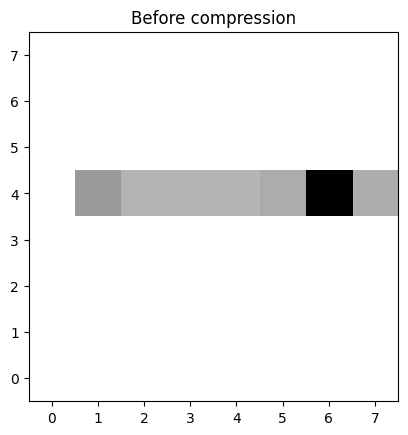

After: (1, 8, 8)
After compression
Perplexity: 0.0


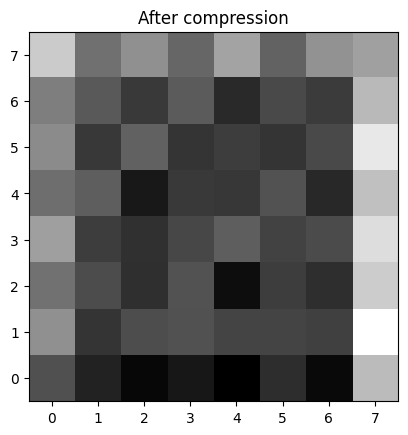

Epoch 2/80: 100%|██████████| 124/124 [00:00<00:00, 772.73it/s, Loss=406]


Epoch [2/80] Average Loss: 569.1925


Epoch 3/80: 100%|██████████| 124/124 [00:00<00:00, 758.44it/s, Loss=406]


Epoch [3/80] Average Loss: 569.1925


Epoch 4/80: 100%|██████████| 124/124 [00:00<00:00, 750.05it/s, Loss=406]


...

Epoch [9/80] Average Loss: 569.1925


Epoch 10/80: 100%|██████████| 124/124 [00:00<00:00, 769.36it/s, Loss=406]


Epoch [10/80] Average Loss: 569.1924


Epoch 11/80: 100%|██████████| 124/124 [00:00<00:00, 762.81it/s, Loss=406]


Epoch [11/80] Average Loss: 569.1924
Before compression
Before: (128, 8, 8)


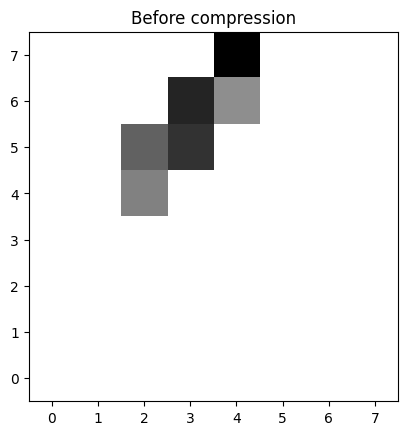

After: (1, 8, 8)
After compression
Perplexity: 0.0


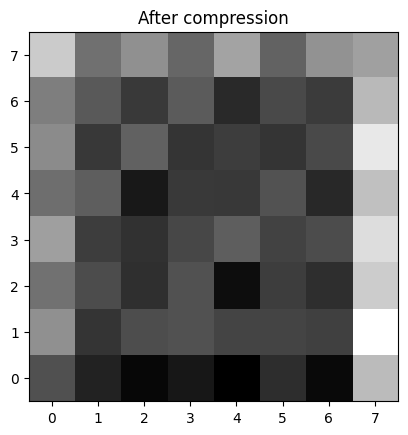

Epoch 12/80: 100%|██████████| 124/124 [00:00<00:00, 757.65it/s, Loss=406]


Epoch [12/80] Average Loss: 569.1924


Epoch 13/80: 100%|██████████| 124/124 [00:00<00:00, 689.31it/s, Loss=406]


Epoch [13/80] Average Loss: 569.1924


Epoch 14/80: 100%|██████████| 124/124 [00:00<00:00, 716.99it/s, Loss=406]


...

Epoch [19/80] Average Loss: 569.1923


Epoch 20/80: 100%|██████████| 124/124 [00:00<00:00, 752.39it/s, Loss=406]


Epoch [20/80] Average Loss: 569.1923


Epoch 21/80: 100%|██████████| 124/124 [00:00<00:00, 736.72it/s, Loss=406]


Epoch [21/80] Average Loss: 569.1923
Before compression
Before: (128, 8, 8)


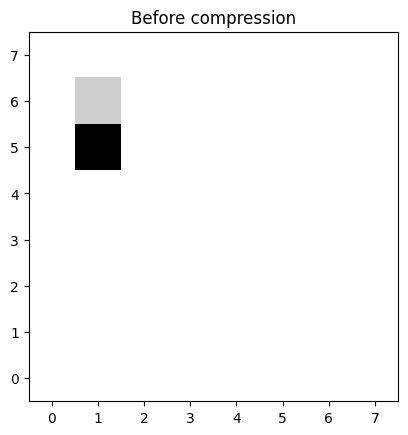

After: (1, 8, 8)
After compression
Perplexity: 0.0


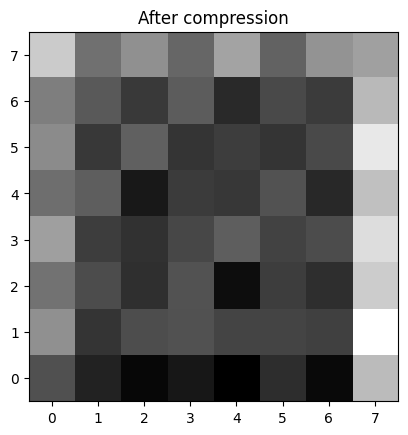

Epoch 22/80: 100%|██████████| 124/124 [00:00<00:00, 751.35it/s, Loss=406]


Epoch [22/80] Average Loss: 569.1923


Epoch 23/80: 100%|██████████| 124/124 [00:00<00:00, 727.67it/s, Loss=406]


Epoch [23/80] Average Loss: 569.1923


Epoch 24/80: 100%|██████████| 124/124 [00:00<00:00, 745.12it/s, Loss=406]


...

Epoch [29/80] Average Loss: 569.1922


Epoch 30/80: 100%|██████████| 124/124 [00:00<00:00, 746.24it/s, Loss=406]


Epoch [30/80] Average Loss: 569.1922


Epoch 31/80: 100%|██████████| 124/124 [00:00<00:00, 738.64it/s, Loss=406]


Epoch [31/80] Average Loss: 569.1922
Before compression
Before: (128, 8, 8)


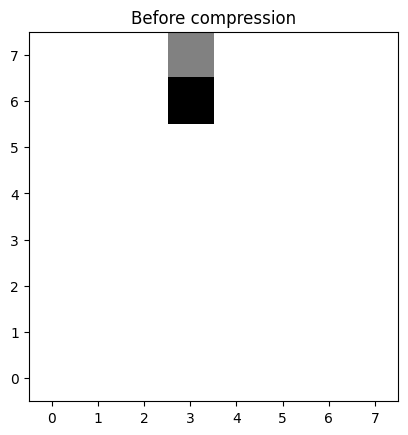

After: (1, 8, 8)
After compression
Perplexity: 0.0


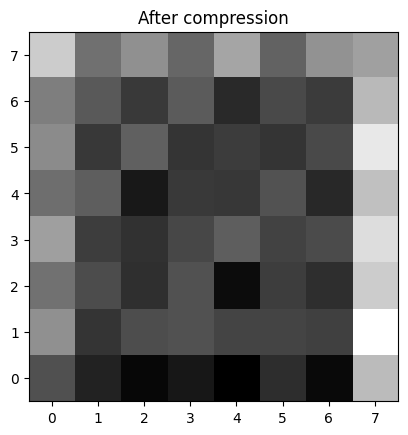

Epoch 32/80: 100%|██████████| 124/124 [00:00<00:00, 735.67it/s, Loss=406]


Epoch [32/80] Average Loss: 569.1921


Epoch 33/80: 100%|██████████| 124/124 [00:00<00:00, 702.08it/s, Loss=406]


Epoch [33/80] Average Loss: 569.1921


Epoch 34/80: 100%|██████████| 124/124 [00:00<00:00, 702.23it/s, Loss=406]


...

Epoch [39/80] Average Loss: 569.1921


Epoch 40/80: 100%|██████████| 124/124 [00:00<00:00, 756.87it/s, Loss=406]


Epoch [40/80] Average Loss: 569.1920


Epoch 41/80: 100%|██████████| 124/124 [00:00<00:00, 758.31it/s, Loss=406]


Epoch [41/80] Average Loss: 569.1920
Before compression
Before: (128, 8, 8)


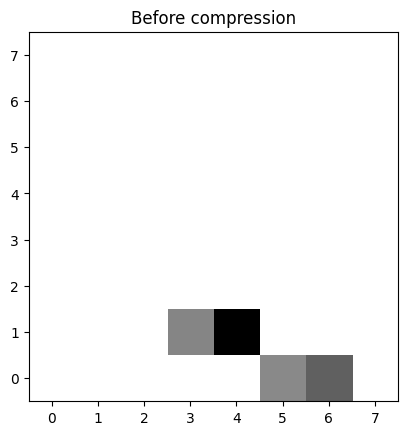

After: (1, 8, 8)
After compression
Perplexity: 0.0


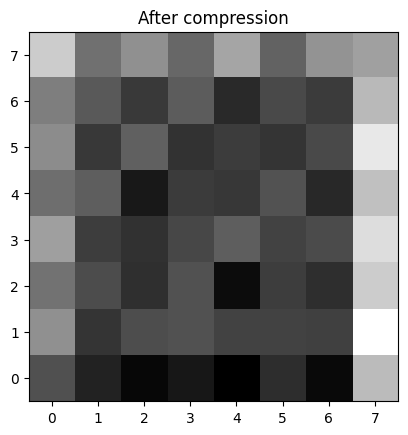

Epoch 42/80: 100%|██████████| 124/124 [00:00<00:00, 719.56it/s, Loss=406]


Epoch [42/80] Average Loss: 569.1920


Epoch 43/80: 100%|██████████| 124/124 [00:00<00:00, 727.27it/s, Loss=406]


Epoch [43/80] Average Loss: 569.1920


Epoch 44/80: 100%|██████████| 124/124 [00:00<00:00, 760.35it/s, Loss=406]


...

Epoch [49/80] Average Loss: 569.1919


Epoch 50/80: 100%|██████████| 124/124 [00:00<00:00, 679.50it/s, Loss=406]


Epoch [50/80] Average Loss: 569.1919


Epoch 51/80: 100%|██████████| 124/124 [00:00<00:00, 679.15it/s, Loss=406]


Epoch [51/80] Average Loss: 569.1919
Before compression
Before: (128, 8, 8)


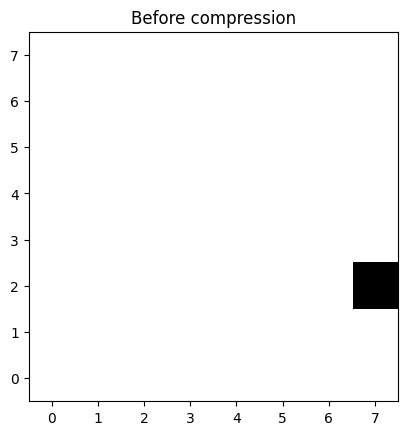

After: (1, 8, 8)
After compression
Perplexity: 0.0


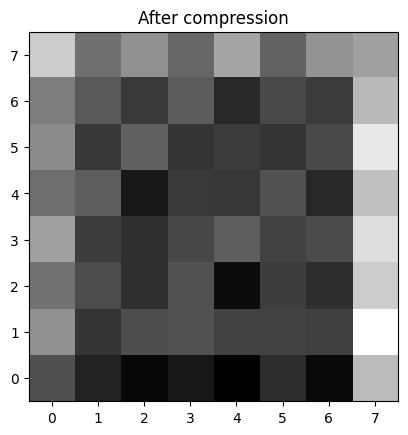

Epoch 52/80: 100%|██████████| 124/124 [00:00<00:00, 727.57it/s, Loss=406]


Epoch [52/80] Average Loss: 569.1919


Epoch 53/80: 100%|██████████| 124/124 [00:00<00:00, 734.05it/s, Loss=406]


Epoch [53/80] Average Loss: 569.1919


Epoch 54/80: 100%|██████████| 124/124 [00:00<00:00, 722.31it/s, Loss=406]


...

Epoch [59/80] Average Loss: 569.1918


Epoch 60/80: 100%|██████████| 124/124 [00:00<00:00, 701.99it/s, Loss=406]


Epoch [60/80] Average Loss: 569.1918


Epoch 61/80: 100%|██████████| 124/124 [00:00<00:00, 721.14it/s, Loss=406]


Epoch [61/80] Average Loss: 569.1918
Before compression
Before: (128, 8, 8)


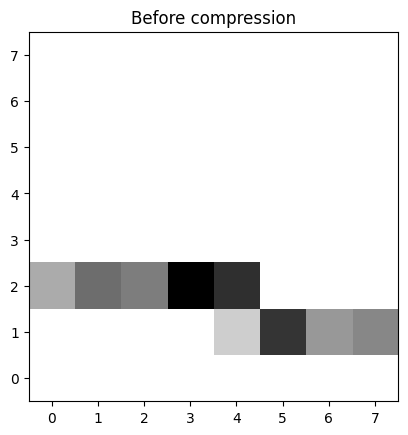

After: (1, 8, 8)
After compression
Perplexity: 0.0


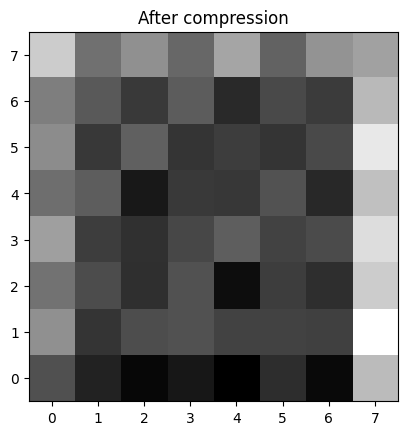

Epoch 62/80: 100%|██████████| 124/124 [00:00<00:00, 727.09it/s, Loss=406]


Epoch [62/80] Average Loss: 569.1918


Epoch 63/80: 100%|██████████| 124/124 [00:00<00:00, 736.77it/s, Loss=406]


Epoch [63/80] Average Loss: 569.1917


Epoch 64/80: 100%|██████████| 124/124 [00:00<00:00, 736.02it/s, Loss=406]


...

Epoch [69/80] Average Loss: 569.1917


Epoch 70/80: 100%|██████████| 124/124 [00:00<00:00, 741.33it/s, Loss=406]


Epoch [70/80] Average Loss: 569.1917


Epoch 71/80: 100%|██████████| 124/124 [00:00<00:00, 750.03it/s, Loss=406]


Epoch [71/80] Average Loss: 569.1916
Before compression
Before: (128, 8, 8)


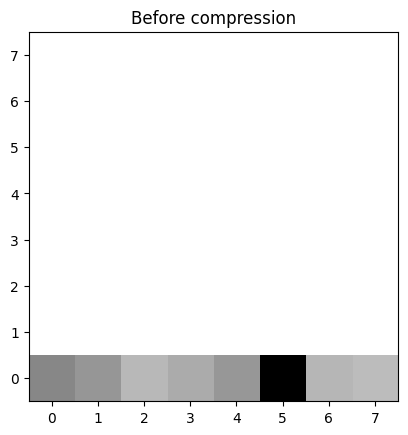

After: (1, 8, 8)
After compression
Perplexity: 0.0


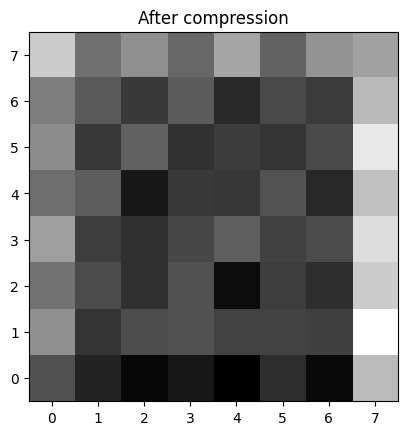

Epoch 72/80: 100%|██████████| 124/124 [00:00<00:00, 749.76it/s, Loss=406]


Epoch [72/80] Average Loss: 569.1916


Epoch 73/80: 100%|██████████| 124/124 [00:00<00:00, 748.01it/s, Loss=406]


Epoch [73/80] Average Loss: 569.1916


Epoch 74/80: 100%|██████████| 124/124 [00:00<00:00, 752.24it/s, Loss=406]


...

Epoch [78/80] Average Loss: 569.1915


Epoch 79/80: 100%|██████████| 124/124 [00:00<00:00, 743.87it/s, Loss=406]


Epoch [79/80] Average Loss: 569.1915


Epoch 80/80: 100%|██████████| 124/124 [00:00<00:00, 766.99it/s, Loss=406]

Epoch [80/80] Average Loss: 569.1915


In [72]:
# loss
average_loss_values = []
# ssim
ssim_values = []

# perplexity
perplexity_values = []

idx_validation = 0
patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    perplexity_per_epoch = 0
    
    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
        
        X_adcs_tr = X_adcs.unsqueeze(1).permute(0, 1, 2, 3)
        
        (
            recon_patch, 
            vq_loss, 
            perplexity,
            encodings,
            codebooks
        ) = model(
           X_adcs_tr
        )
        
        recon_patch = recon_patch.float().to(device)      
        
        loss = _get_vq_loss(recon_patch, X_adcs_tr, vq_loss)
        loss.backward()
        train_loss += loss.item()
        perplexity_per_epoch += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    perplexity_values.append(perplexity_per_epoch / len(train_loader))
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            (
                recon_patch, 
                vq_loss, 
                perplexity, 
                encodings,
                codebooks         
            ) = model(patch_test)
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            print(f"Perplexity: {perplexity}")
            
            plot_patch(recon_patch_np[0], "After compression")
        

In [73]:
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.026214998215436935
encoder.0.bias 0.0001453390286769718
encoder.2.weight 0.031141962856054306
encoder.2.bias 0.0004701040161307901
encoder.4.weight 0.09095123410224915
encoder.4.bias 0.0011170729994773865
encoder.6.weight 0.045854516327381134
encoder.6.bias 2.2399582189081002e-09
encoder.7.weight 0.05055916681885719
encoder.7.bias 0.00369286653585732
vq_layer.embedding.weight 0.11697312444448471
decoder.0.weight 0.00016937700274866074
decoder.0.bias 0.012758920900523663
decoder.2.weight 0.020223278552293777
decoder.2.bias 0.1551447957754135
decoder.4.weight 0.1070486381649971
decoder.4.bias 1.1578850746154785
decoder.6.weight 0.4728560149669647
decoder.6.bias 1.569001317024231


In [74]:
# Test model with unseen data
events_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]

events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(events_test_patches_adcs)}")
print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [75]:
X_test_patch = events_test_patches_adcs[0][0]
X_test = torch.tensor(X_test_patch).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).permute(1, 0, 2).unsqueeze(1)


In [76]:
model.eval()

print("Compression quality measurements")

#    return (
#            x_recon, 
#            vq_loss, 
#            perplexity,        
#            encodings
#         )

with torch.no_grad():
    model = VQVAE(
        hidden_channels = 4,
        kernel_size = 4,
        slope = 0.05 
    ).to(device)
    X_test = X_test.permute(1, 0, 2, 3)
    print(X_test.shape)
    z = model.encoder(X_test)
    # z, vq_loss, perplexity, encodings, _ = model.vq_layer(z)
    z_q, loss, perplexity, encodings, codebooks = model.vq_layer(z)
    
    
    print(f"Encoded patch shape (Codebook): {codebooks.shape}")
    print(codebooks)
    
    print(f"Latent shape: {z_q.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    
    print(f"Codebook unique encodings:{len(used_codes)}")
    print(encodings.shape)
    encoded_width, encoded_height = codebooks.shape
    
    print(encodings.unique())
    
    codebook = model.vq_layer.embedding.weight
    codebook_size = codebook.element_size() * codebook.numel()
    
    print(f"Codebook size: {len(used_codes)}")
    
    # X_test_bits = _get_bits_from_tensor(X_test)
    
    # compression_ratio = _get_compression_ratio(X_test, num_embeddings, encodings.numel())
    # print(f"Compression ratio: {compression_ratio}")
    
    # patch_bits = _get_patch_bits(num_embeddings, encodings.numel())
    # print(f"Tensor bits: {X_test_bits}")
    # print(f"Used patch bits: {patch_bits}")
    
    # TOtal codebook size
    print(f"Embedding shape: {encodings.shape}")
    print(f"Encodings: {encodings}")
    
    n_hits_total = 0
    for event_test in events_test[:SELECTED_EVENTS]:
        n_hits_total += len(event_test)
    
        
    print(f"Test event hits: {n_hits_total}")
    total_hit_bits = _get_total_hit_bits(n_hits_total)
    print(f"Total hit bits: {total_hit_bits}")
    
    patch_amount = _get_patch_count(events_test[0])
    print(f"Patch amount: {patch_amount}")
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount=patch_amount,
        encoded_patch_size=(encoded_width, encoded_height, num_embeddings),
        patch_size=PATCH_SIZE
    )
    print(f"Total patch bits: {total_patch_bits}")
    
    compression_ratio = _get_compression_ratio(
        n_hits_total, 
        patch_amount,
        (encoded_width, encoded_height, num_embeddings),
        PATCH_SIZE
    )
    print(f"Compression ratio: {compression_ratio}")
    
    encoded_patch_bits = _get_encoded_patch_bits((encoded_width, encoded_height, num_embeddings), PATCH_SIZE)
    print(f"Encoded patch: {encoded_patch_bits} bits")
    print(f"Encodings size: {encodings.numel()}")
    
    # print(len(train_loader) + len(events_test_loaders[0]))
    # print(_get_encoded_patch_bits((encodings.numel(), 1, num_embeddings), PATCH_SIZE))
    
    # print(encodings.shape)
    

Compression quality measurements
Using params for VQ: 256, 16
torch.Size([1, 1, 8, 8])
Encoded patch shape (Codebook): torch.Size([4, 16])
tensor([[-0.0014,  0.0005, -0.0030, -0.0032,  0.0030,  0.0031, -0.0037,  0.0026,
         -0.0028, -0.0013,  0.0037,  0.0002, -0.0016,  0.0005,  0.0030, -0.0031],
        [-0.0014,  0.0005, -0.0030, -0.0032,  0.0030,  0.0031, -0.0037,  0.0026,
         -0.0028, -0.0013,  0.0037,  0.0002, -0.0016,  0.0005,  0.0030, -0.0031],
        [ 0.0006,  0.0027, -0.0008,  0.0036, -0.0005, -0.0011,  0.0024, -0.0020,
         -0.0001,  0.0029,  0.0002,  0.0019,  0.0036,  0.0025, -0.0009, -0.0020],
        [-0.0017,  0.0012,  0.0034,  0.0013,  0.0016, -0.0037,  0.0030, -0.0039,
          0.0036, -0.0023, -0.0027,  0.0018, -0.0033,  0.0024, -0.0034,  0.0022]],
       device='cuda:0')
Latent shape: torch.Size([1, 16, 2, 2])
Codebook unique encodings:3
torch.Size([4])
tensor([ 86, 142, 252], device='cuda:0')
Codebook size: 3
Embedding shape: torch.Size([4])
Encodings